# Immediate baseline models

In [65]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelBinarizer
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
from sklearn.preprocessing import LabelBinarizer
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelBinarizer, LabelEncoder
import joblib

In [66]:
df = pd.read_csv('../../data/clean/full_data.csv')

In [67]:
df.head()

,casos,week_canton,rr,clasi_rr,clasi_rr_no_0,urb,aedes_aegypti,criaderos_de_mosquito,dengue,fiebre,...,precip_median_lag_2,precip_median_lag_1,precip_min_lag_8,precip_min_lag_7,precip_min_lag_6,precip_min_lag_5,precip_min_lag_4,precip_min_lag_3,precip_min_lag_2,precip_min_lag_1
0,4,2020-9-101,0.459451,Medio,Bajo,1,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2,2020-10-101,0.224397,Medio,Bajo,1,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2,2020-11-101,0.253939,Medio,Bajo,1,0.0,0.0,0.0,11.34,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,2020-12-101,0.000000,Bajo,Bajo,1,0.0,0.0,0.0,10.60,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,2020-13-101,0.000000,Bajo,Bajo,1,0.0,0.0,0.0,0.00,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [68]:
df.drop(columns=['casos'], inplace=True)
df.drop(columns = ["rr"], inplace = True)
df.drop(columns = ["clasi_rr_no_0"], inplace = True)
df.drop(columns = ["tmax_mean"], inplace = True)
df.drop(columns = ["tmin_mean"], inplace = True)
df.drop(columns = ["temp_prom"], inplace = True)
df.drop(columns = ["precip_total"], inplace = True)
df.drop(columns = ["precip_max"], inplace = True)
df.drop(columns = ["precip_min"], inplace = True)
df.drop(columns = ["precip_median"], inplace = True)
df.drop(columns = ["precip_mean"], inplace = True)
df.drop(columns = ["ndvi"], inplace = True)
df.drop(columns = ["aedes_aegypti"], inplace = True)
df.drop(columns = ["criaderos_de_mosquito"], inplace = True)
df.drop(columns = ["fiebre"], inplace = True)
df.drop(columns = ["plaquetas"], inplace = True)
df.drop(columns = ["buscar_trabajo"], inplace = True)
df.drop(columns = ["desempleo"], inplace = True)
df.drop(columns = ["empleo"], inplace = True)
df.drop(columns = ["comprar_carro"], inplace = True)
df.drop(columns = ["préstamo"], inplace = True)
df.drop(columns = ["tiquetes_avion"], inplace = True)
df.drop(columns = ["vacaciones"], inplace = True)
df.drop(columns = ["corte_agua"], inplace = True)
df.drop(columns = ["corte_de_agua"], inplace = True)
df.drop(columns = ["suspension_de_agua"], inplace = True)
df.drop(columns = ["dengue"], inplace = True)

In [69]:
df.drop(columns = ["rr_lag_1"], inplace = True)
df.drop(columns = ["casos_lag_1"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_1"], inplace = True)
df.drop(columns = ["rr_lag_2"], inplace = True)
df.drop(columns = ["casos_lag_2"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_2"], inplace = True)
df.drop(columns = ["rr_lag_3"], inplace = True)
df.drop(columns = ["casos_lag_3"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_3"], inplace = True)
df.drop(columns = ["rr_lag_4"], inplace = True)
df.drop(columns = ["casos_lag_4"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_4"], inplace = True)
df.drop(columns = ["rr_lag_5"], inplace = True)
df.drop(columns = ["casos_lag_5"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_5"], inplace = True)
df.drop(columns = ["rr_lag_6"], inplace = True)
df.drop(columns = ["casos_lag_6"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_6"], inplace = True)
df.drop(columns = ["rr_lag_7"], inplace = True)
df.drop(columns = ["casos_lag_7"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_7"], inplace = True)
df.drop(columns = ["rr_lag_8"], inplace = True)
df.drop(columns = ["casos_lag_8"], inplace = True)
df.drop(columns = ["clasi_rr_no_0_lag_8"], inplace = True)

In [70]:
df.shape

(24928, 212)

In [71]:
df = pd.get_dummies(df, columns = ["urb"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_1"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_2"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_3"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_4"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_5"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_6"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_7"])
df = pd.get_dummies(df, columns = ["clasi_rr_lag_8"])

In [72]:
df.head()

,week_canton,clasi_rr,nino34ssta,ndvi_lag_8,ndvi_lag_7,ndvi_lag_6,ndvi_lag_5,ndvi_lag_4,ndvi_lag_3,ndvi_lag_2,...,clasi_rr_lag_5_Medio,clasi_rr_lag_6_Alto,clasi_rr_lag_6_Bajo,clasi_rr_lag_6_Medio,clasi_rr_lag_7_Alto,clasi_rr_lag_7_Bajo,clasi_rr_lag_7_Medio,clasi_rr_lag_8_Alto,clasi_rr_lag_8_Bajo,clasi_rr_lag_8_Medio
0,2020-9-101,Medio,0.392222,0.614200,0.589488,0.562849,0.515343,0.471457,0.445589,0.446709,...,False,True,False,False,True,False,False,False,False,True
1,2020-10-101,Medio,0.411116,0.589488,0.562849,0.515343,0.471457,0.445589,0.446709,0.444844,...,False,True,False,False,True,False,False,True,False,False
2,2020-11-101,Medio,0.453418,0.562849,0.515343,0.471457,0.445589,0.446709,0.444844,0.428539,...,True,False,True,False,True,False,False,True,False,False
3,2020-12-101,Bajo,0.474281,0.515343,0.471457,0.445589,0.446709,0.444844,0.428539,0.411972,...,False,False,False,True,False,True,False,True,False,False
4,2020-13-101,Bajo,0.449209,0.471457,0.445589,0.446709,0.444844,0.428539,0.411972,0.356043,...,True,True,False,False,False,False,True,False,True,False


In [73]:
train = df[df['week_canton'] < '2024-1-101']
val = df[(df['week_canton'] >= '2024-1-101') & (df['week_canton'] < '2025-1-101')]
test = df[df['week_canton'] >= '2025-1-101']

X_train = train.drop(columns = ["clasi_rr", "week_canton"])
y_train = train["clasi_rr"]

X_val = val.drop(columns = ["clasi_rr", "week_canton"])
y_val= val["clasi_rr"]

X_test= test.drop(columns = ["clasi_rr", "week_canton"])
y_test = test["clasi_rr"]

In [74]:
scaler = StandardScaler()  

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=X_val.columns)  
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

In [75]:
X_test_for_reg = pd.concat([X_val, X_test], axis=0)
y_test_for_reg = pd.concat([y_val, y_test], axis=0)
val_test = pd.concat([val, test], axis=0)

X_test_for_reg_scaled = pd.DataFrame(scaler.transform(X_test_for_reg), columns=X_test_for_reg.columns)

In [76]:
train.shape, val.shape, test.shape

((16400, 230), (4264, 230), (4264, 230))

## Logistic regression

In [77]:
reg = LogisticRegression()

reg.fit(X_train_scaled, y_train)

y_pred_reg = reg.predict(X_test_for_reg_scaled)

c:\Users\nan\OneDrive - Universidad de Costa Rica\cuenta personal\ucr pers\practica profesional\practica dengue\dengue-model\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [78]:
results_reg = pd.DataFrame({
    'actual': y_test_for_reg,   
    'pred': y_pred_reg,
    "week_canton": val_test["week_canton"].values
})

results_reg.to_csv('../../data/model_results/results_clasi_rr_reg.csv')

In [79]:
print(classification_report(y_test_for_reg, y_pred_reg))

              precision    recall  f1-score   support

        Alto       0.72      0.69      0.70      3190
        Bajo       0.72      0.81      0.77      4071
       Medio       0.58      0.42      0.49      1267

    accuracy                           0.71      8528
   macro avg       0.68      0.64      0.65      8528
weighted avg       0.70      0.71      0.70      8528



In [80]:
y_score_reg = reg.predict_proba(X_test_for_reg)

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test_for_reg)

In [81]:
def roc_auc_metrics_log(class_of_interest, other_classes):
    class_id = np.flatnonzero(label_binarizer.classes_ == class_of_interest)[0]

    display = RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        y_score_reg[:, class_id],
        name=f"{class_of_interest} contra el resto",
        curve_kwargs=dict(color="darkorange"),
        plot_chance_level=True,
        despine=True,
    )
    _ = display.ax_.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=f"One-vs-Rest ROC curves:\n{class_of_interest} vs ({other_classes[0]} and {other_classes[1]})",
    )

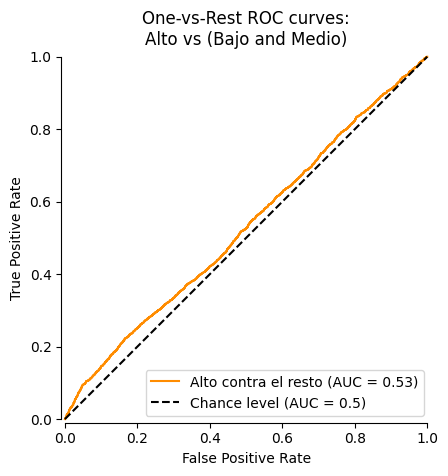

In [82]:
roc_auc_metrics_log("Alto", ["Bajo", "Medio"])

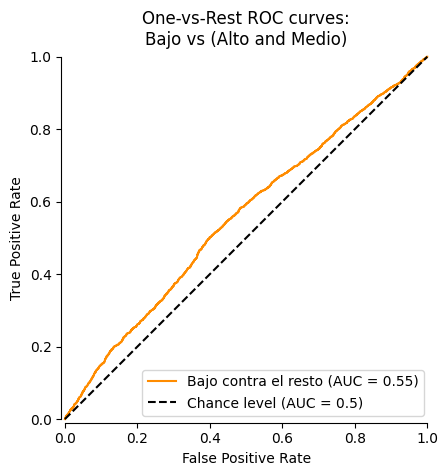

In [83]:
roc_auc_metrics_log("Bajo", ["Alto", "Medio"])

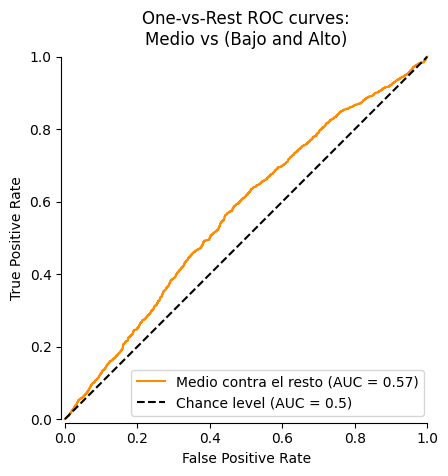

In [84]:
roc_auc_metrics_log("Medio", ["Bajo", "Alto"])

In [85]:
cnf_matrix_reg = confusion_matrix(y_test_for_reg, y_pred_reg)
cnf_matrix_reg

array([[2195,  833,  162],
       [ 540, 3311,  220],
       [ 305,  433,  529]])

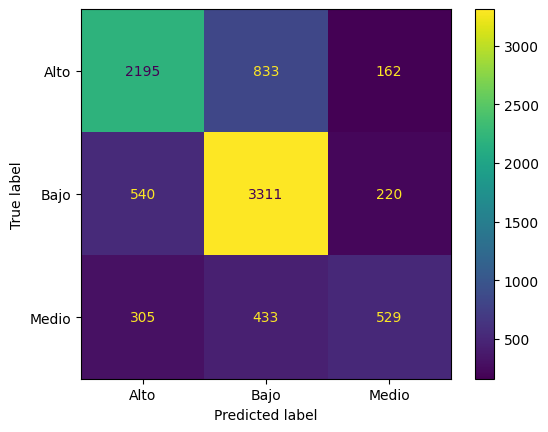

In [86]:
clasi = ["Alto", "Bajo", "Medio"]
ConfusionMatrixDisplay(confusion_matrix=cnf_matrix_reg, display_labels = clasi).plot()

In [87]:
coef_df = pd.DataFrame({"Feature": X_train.columns, "Coefficient": reg.coef_[0]})
sd = pd.DataFrame({"Feature": X_train.columns, "Std": X_train_scaled.std()})
coef_df = coef_df.merge(sd, on = "Feature")
coef_df["Coefficient_std"] = coef_df["Coefficient"] * coef_df["Std"]
coef_reg_sorted = coef_df.sort_values(by = "Coefficient_std", ascending=False)

coef_reg_sorted

,Feature,Coefficient,Std,Coefficient_std
12,tmax_mean_lag_5,0.288682,1.00003,0.288691
17,tmin_mean_lag_8,0.241925,1.00003,0.241933
204,clasi_rr_lag_1_Alto,0.210228,1.00003,0.210235
16,tmax_mean_lag_1,0.197245,1.00003,0.197251
207,clasi_rr_lag_2_Alto,0.160302,1.00003,0.160307
...,...,...,...,...
205,clasi_rr_lag_1_Bajo,-0.127366,1.00003,-0.127370
37,temp_prom_lag_4,-0.129317,1.00003,-0.129321
24,tmin_mean_lag_1,-0.161847,1.00003,-0.161852
13,tmax_mean_lag_4,-0.204147,1.00003,-0.204153


Text(0.5, 0, 'Coefficient')

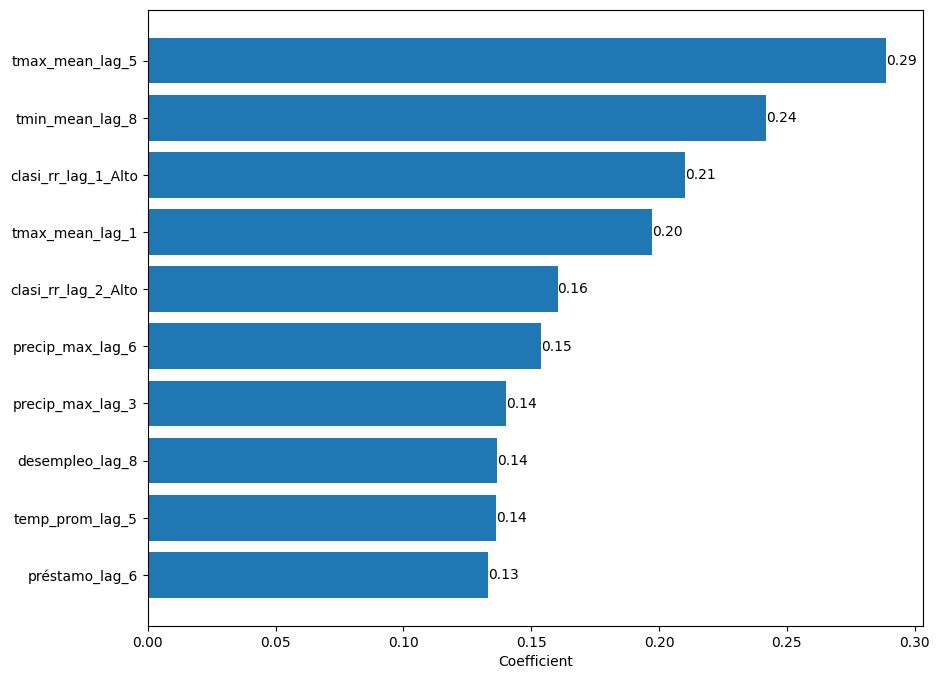

In [88]:
fig, ax = plt.subplots(figsize=(10, 8))
coef_reg_sorted = coef_df.sort_values(by = "Coefficient_std", ascending=True)
ax.barh(coef_reg_sorted["Feature"].tail(10), coef_reg_sorted["Coefficient_std"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Coefficient")

### Random forest

In [89]:
rf = RandomForestClassifier(oob_score=True)

param_grid_rf = {
    'max_depth': [5],
    'min_samples_split': [10],
    'ccp_alpha': [0], 
    "criterion": ["gini"]
}

# param_grid_rf = {
#     'max_depth': [5, 6, 7, 8],
#     'min_samples_split': [10, 100, 500],
#     'ccp_alpha': [0, 1 /  10**5, 1 / 10**4, 1 / 10**3, 0.01, 0.1, 1, 10], 
#     "criterion": ["gini", "entropy"]
# }

# 3. Initialize and run Grid Search
grid_rf = GridSearchCV(estimator=rf, param_grid=param_grid_rf, cv = 5, n_jobs=-1, verbose=10)
grid_rf.fit(X_train, y_train)

Fitting 5 folds for each of 1 candidates, totalling 5 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ob_score=True)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'ccp_alpha': [0], 'criterion': ['gini'], 'max_depth': [5], 'min_samples_split': [10]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the sc

In [90]:
# joblib.dump(grid_rf, "../models/clasi_rf.pkl")

In [91]:
y_pred_rf = grid_rf.predict(X_test_for_reg)

In [92]:
results_rf = pd.DataFrame({
    'actual': y_test_for_reg,   
    'pred': y_pred_rf,
    "week_canton": val_test["week_canton"].values
})

results_rf.to_csv('../../data/model_results/results_clasi_rr_rf.csv')

In [93]:
y_score_rf = grid_rf.predict_proba(X_test_for_reg)

label_binarizer = LabelBinarizer().fit(y_train)
y_onehot_test = label_binarizer.transform(y_test_for_reg)

In [94]:
def roc_auc_metrics_rf(class_of_interest, other_classes):
    class_id = np.flatnonzero(label_binarizer.classes_ == class_of_interest)[0]

    display = RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        y_score_rf[:, class_id],
        name=f"{class_of_interest} contra el resto",
        curve_kwargs=dict(color="darkorange"),
        plot_chance_level=True,
        despine=True,
    )
    _ = display.ax_.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=f"One-vs-Rest ROC curves:\n{class_of_interest} vs ({other_classes[0]} and {other_classes[1]})",
    )

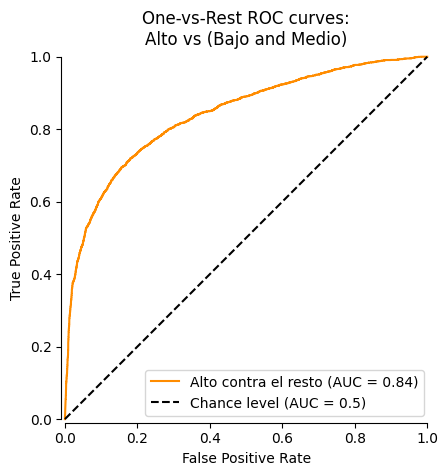

In [95]:
roc_auc_metrics_rf("Alto", ["Bajo", "Medio"])

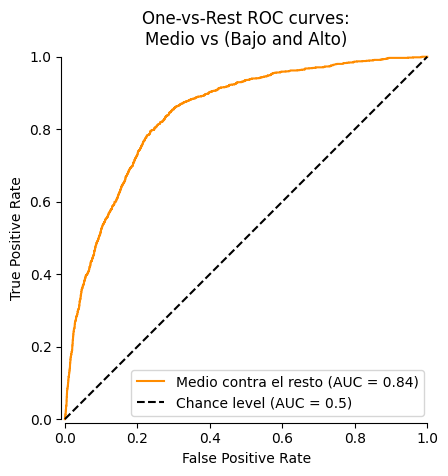

In [96]:
roc_auc_metrics_rf("Medio", ["Bajo", "Alto"])

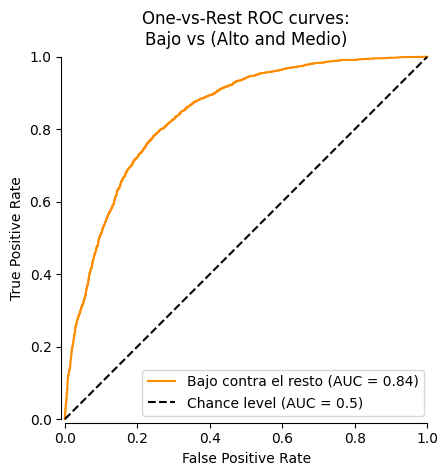

In [97]:
roc_auc_metrics_rf("Bajo", ["Alto", "Medio"])

In [98]:
print(classification_report(y_test_for_reg, y_pred_rf))

              precision    recall  f1-score   support

        Alto       0.75      0.65      0.70      3190
        Bajo       0.67      0.90      0.77      4071
       Medio       0.66      0.14      0.23      1267

    accuracy                           0.69      8528
   macro avg       0.69      0.56      0.56      8528
weighted avg       0.70      0.69      0.66      8528



In [99]:
cnf_matrix_rf = confusion_matrix(y_test_for_reg, y_pred_rf)
cnf_matrix_rf

array([[2067, 1087,   36],
       [ 352, 3666,   53],
       [ 339,  755,  173]])

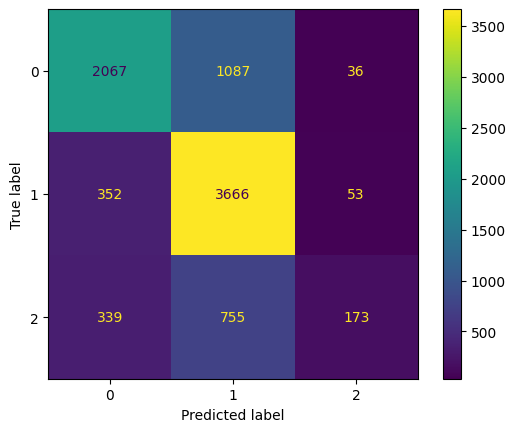

In [100]:
ConfusionMatrixDisplay(confusion_matrix=cnf_matrix_rf).plot()

In [101]:
imp_rf_df = pd.DataFrame({"Feature": X_train.columns, "Importance": grid_rf.best_estimator_.feature_importances_})
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=False)

imp_rf_sorted

,Feature,Importance
205,clasi_rr_lag_1_Bajo,0.108353
204,clasi_rr_lag_1_Alto,0.087526
208,clasi_rr_lag_2_Bajo,0.076010
211,clasi_rr_lag_3_Bajo,0.063053
207,clasi_rr_lag_2_Alto,0.060665
...,...,...
119,tiquetes_avion_lag_2,0.000000
125,vacaciones_lag_4,0.000000
128,vacaciones_lag_1,0.000000
129,corte_agua_lag_8,0.000000


Text(0.5, 0, 'Importance')

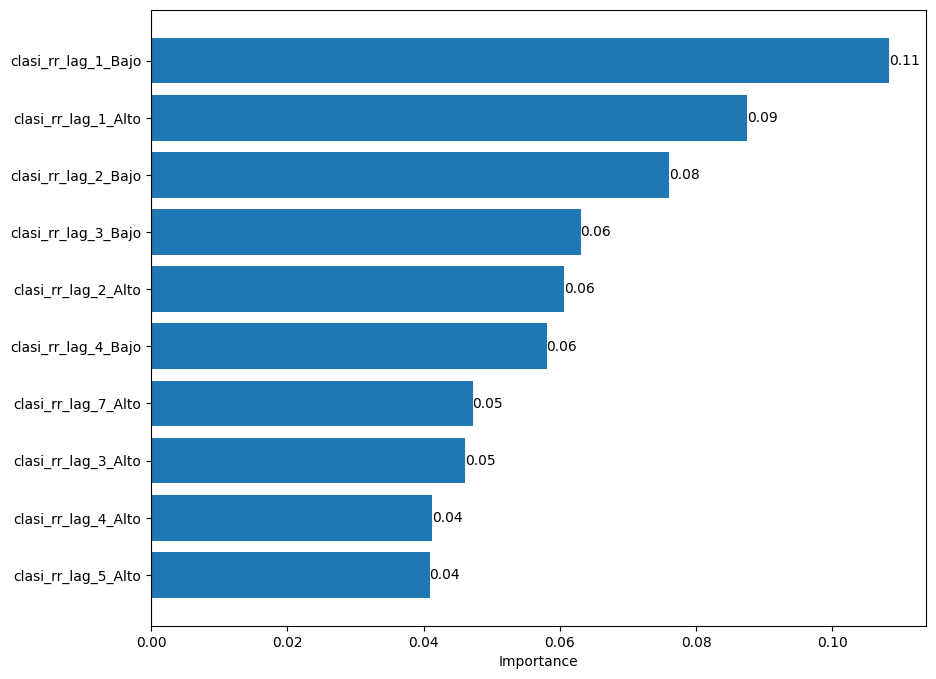

In [102]:
fig, ax = plt.subplots(figsize=(10, 8))
imp_rf_sorted = imp_rf_df.sort_values(by = "Importance", ascending=True)
ax.barh(imp_rf_sorted["Feature"].tail(10), imp_rf_sorted["Importance"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Importance")

## XGBoost

In [103]:
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test_for_reg)

In [104]:
xgb = XGBClassifier()

param_grid_xgb = {
    'max_depth': [5],
    'learning_rate': [0.3],
    'n_estimator': [50], 
    "criterion": ["auc"],
    "reg_lambda": [0],
}

# param_grid_xgb = {
#     'max_depth': [5, 6, 7, 8],
#     'learning_rate': [0.3, 0.1, 0.05],
#     'n_estimator': [50, 100, 150], 
#     "criterion": ["auc", "logloss"],
#     "reg_lambda": [0, 1 /  10**5, 1 / 10**4, 1 / 10**3, 0.01, 0.1, 1, 10],
# }

grid_xgb = GridSearchCV(estimator=xgb, param_grid=param_grid_xgb, cv = 5, n_jobs=-1, verbose=0)
grid_xgb.fit(X_train, y_train_encoded)

c:\Users\nan\OneDrive - Universidad de Costa Rica\cuenta personal\ucr pers\practica profesional\practica dengue\dengue-model\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:38:51] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "criterion", "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'criterion': ['auc'], 'learning_rate': [0.3], 'max_depth': [5], 'n_estimator': [50], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : 

In [105]:
# joblib.dump(grid_xgb, "../models/clasi_xgb.pkl")

In [106]:
y_pred_xgb = grid_xgb.predict(X_test_for_reg)

In [107]:
results_xgb = pd.DataFrame({
    'actual': y_test_encoded,   
    'pred': y_pred_xgb,
    "week_canton": val_test["week_canton"].values
})

results_xgb.to_csv('../../data/model_results/results_clasi_rr_xgb.csv')

In [108]:
y_score_xgb = grid_xgb.predict_proba(X_test_for_reg)

label_binarizer = LabelBinarizer().fit(y_train_encoded)
y_onehot_test = label_binarizer.transform(y_test_encoded)

In [109]:
classes = ["Alto", "Bajo", "Medio"]
def roc_auc_metrics_xgb(class_of_interest, other_classes):
    class_id = np.flatnonzero(label_binarizer.classes_ == class_of_interest)[0]

    display = RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        y_score_xgb[:, class_id],
        name=f"{classes[class_of_interest]} contra el resto",
        curve_kwargs=dict(color="darkorange"),
        plot_chance_level=True,
        despine=True,
    )
    _ = display.ax_.set(
        xlabel="False Positive Rate",
        ylabel="True Positive Rate",
        title=f"One-vs-Rest ROC curves:\n{classes[class_of_interest]} vs ({classes[other_classes[0]]} and {classes[other_classes[1]]})",
    )

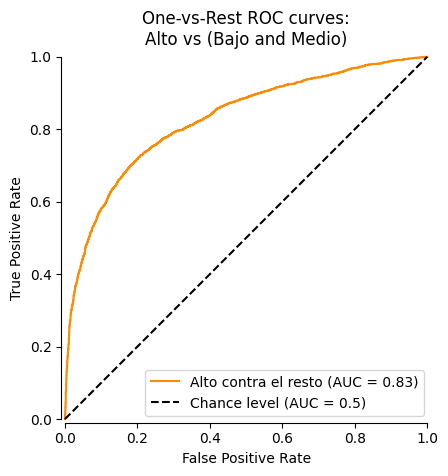

In [110]:
roc_auc_metrics_xgb(0, [1, 2])

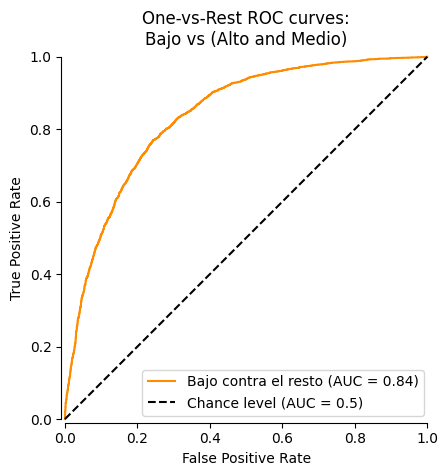

In [111]:
roc_auc_metrics_xgb(1, [0, 2])

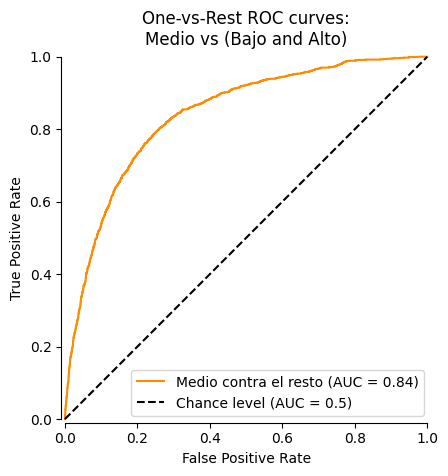

In [112]:
roc_auc_metrics_xgb(2, [1, 0])

In [113]:
print(classification_report(y_test_encoded, y_pred_xgb))

              precision    recall  f1-score   support

           0       0.72      0.67      0.69      3190
           1       0.71      0.83      0.76      4071
           2       0.54      0.34      0.42      1267

    accuracy                           0.70      8528
   macro avg       0.66      0.61      0.62      8528
weighted avg       0.69      0.70      0.68      8528



In [114]:
cnf_matrix_xgb = confusion_matrix(y_test_encoded, y_pred_xgb)
cnf_matrix_xgb

array([[2134,  885,  171],
       [ 518, 3361,  192],
       [ 319,  515,  433]])

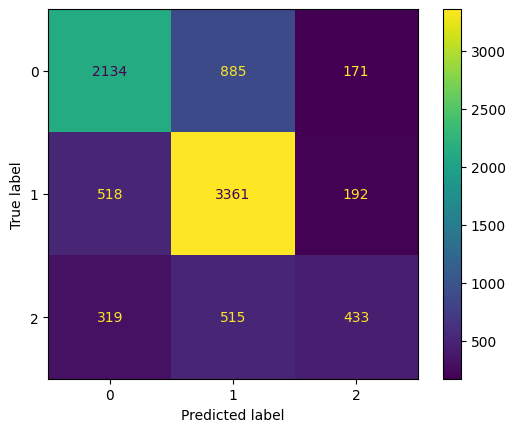

In [115]:
ConfusionMatrixDisplay(confusion_matrix=cnf_matrix_xgb).plot()

In [116]:
imp_xgb_df = pd.DataFrame({"Feature": X_train.columns, "Importance": grid_xgb.best_estimator_.feature_importances_})
imp_xgb_sorted = imp_xgb_df.sort_values(by = "Importance", ascending=False)

imp_xgb_sorted

,Feature,Importance
205,clasi_rr_lag_1_Bajo,0.132671
204,clasi_rr_lag_1_Alto,0.104700
206,clasi_rr_lag_1_Medio,0.081008
207,clasi_rr_lag_2_Alto,0.042524
208,clasi_rr_lag_2_Bajo,0.030828
...,...,...
182,precip_mean_lag_3,0.000000
184,precip_mean_lag_1,0.000000
179,precip_mean_lag_6,0.000000
178,precip_mean_lag_7,0.000000


Text(0.5, 0, 'Importance')

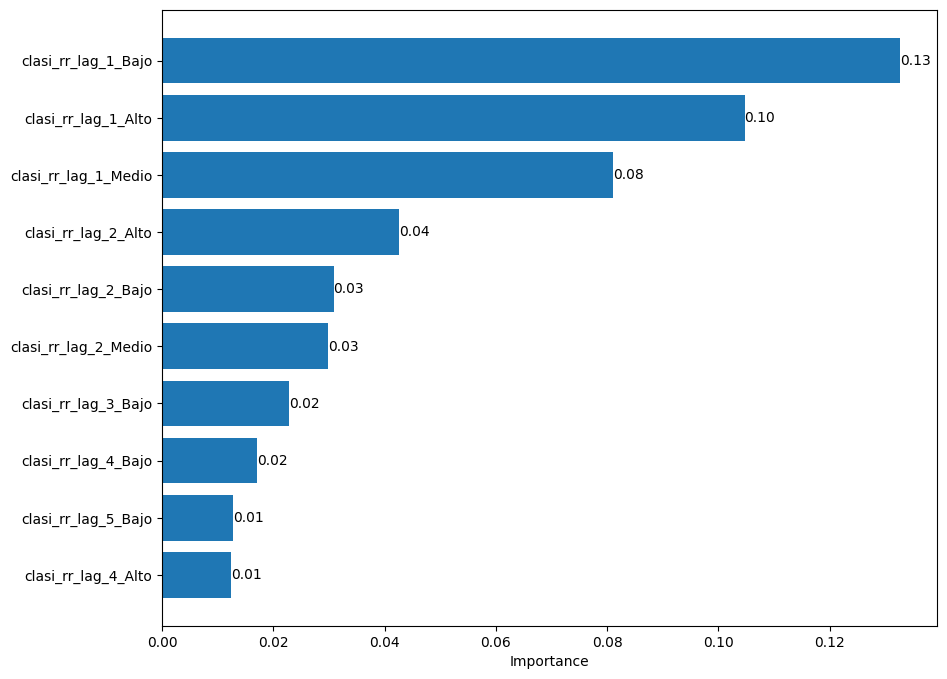

In [117]:
fig, ax = plt.subplots(figsize=(10, 8))
imp_xgb_sorted = imp_xgb_df.sort_values(by = "Importance", ascending=True)
ax.barh(imp_xgb_sorted["Feature"].tail(10), imp_xgb_sorted["Importance"].tail(10))
ax.bar_label(ax.containers[0], fmt='%.2f')
ax.set_xlabel("Importance")

In [118]:
# REMEMBER TO RUN THE CODE WITHOUT URB AND CLASSI DUMMIES

In [119]:
# y_encoded_xgb = OrdinalEncoder().fit_transform(df[["clasi_rr"]])

# df["urb"] = df["urb"].astype("category")
# df["clasi_rr_lag_1"] = df["clasi_rr_lag_1"].astype("category")
# df["clasi_rr_lag_2"] = df["clasi_rr_lag_2"].astype("category")
# df["clasi_rr_lag_3"] = df["clasi_rr_lag_3"].astype("category")
# df["clasi_rr_lag_4"] = df["clasi_rr_lag_4"].astype("category")
# df["clasi_rr_lag_5"] = df["clasi_rr_lag_5"].astype("category")
# df["clasi_rr_lag_6"] = df["clasi_rr_lag_6"].astype("category")
# df["clasi_rr_lag_7"] = df["clasi_rr_lag_7"].astype("category")
# df["clasi_rr_lag_8"] = df["clasi_rr_lag_8"].astype("category")

# train = df[df['week_canton'] < '2024-1-101']
# val = df[(df['week_canton'] >= '2024-1-101') & (df['week_canton'] < '2025-1-101')]
# test = df[df['week_canton'] >= '2025-1-101']

# X_train = train.drop(columns = ["clasi_rr", "week_canton"])
# y_train = y_encoded_xgb[train.index].ravel()

# X_val = val.drop(columns = ["clasi_rr", "week_canton"])
# y_val = y_encoded_xgb[val.index].ravel()

# X_test= test.drop(columns = ["clasi_rr", "week_canton"])
# y_test = y_encoded_xgb[test.index].ravel()

In [120]:
# dtrain = xgb.DMatrix(X_train, y_train, enable_categorical=True)
# dval = xgb.DMatrix(X_val, y_val, enable_categorical=True)
# dtest = xgb.DMatrix(X_test, y_test, enable_categorical=True)

In [121]:
# params = {"objective": "multi:softprob", "tree_method": "hist", "num_class": 3, "eval_metric": ["auc"]}

# n = 100

# xgb_model = xgb.train(
#    params=params,
#    dtrain=dtrain,
#    num_boost_round=n,
#    evals=[(dtrain, "train"), (dval, "validation")],
#    verbose_eval=10, 
#    early_stopping_rounds=50
# )

In [122]:
# xgb_model.best_score

In [123]:
# import numpy as np
# y_pred_proba = xgb_model.predict(dtest)
# y_pred = np.argmax(y_pred_proba, axis=1)

In [124]:
# print(classification_report(y_test, y_pred))

In [125]:
# cnf_matrix_xgb = confusion_matrix(y_test, y_pred)

In [126]:
# ConfusionMatrixDisplay(confusion_matrix=cnf_matrix_xgb).plot()

In [127]:
# importance_xgb = xgb_model.get_score(importance_type="weight")
# importance_xgb_df = pd.DataFrame({"Feature": list(importance_xgb.keys()), "Importance": list(importance_xgb.values())})
# importance_xgb_sorted = importance_xgb_df.sort_values(by = "Importance", ascending=False) 
# importance_xgb_sorted.head(10)

In [128]:
# xgb.plot_importance(xgb_model, max_num_features=10, importance_type="weight")